<a href="https://colab.research.google.com/github/krishnakanthkona-3110/Interview_Prep/blob/main/Interview_3_RAG_Hybrid_Search_Questions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

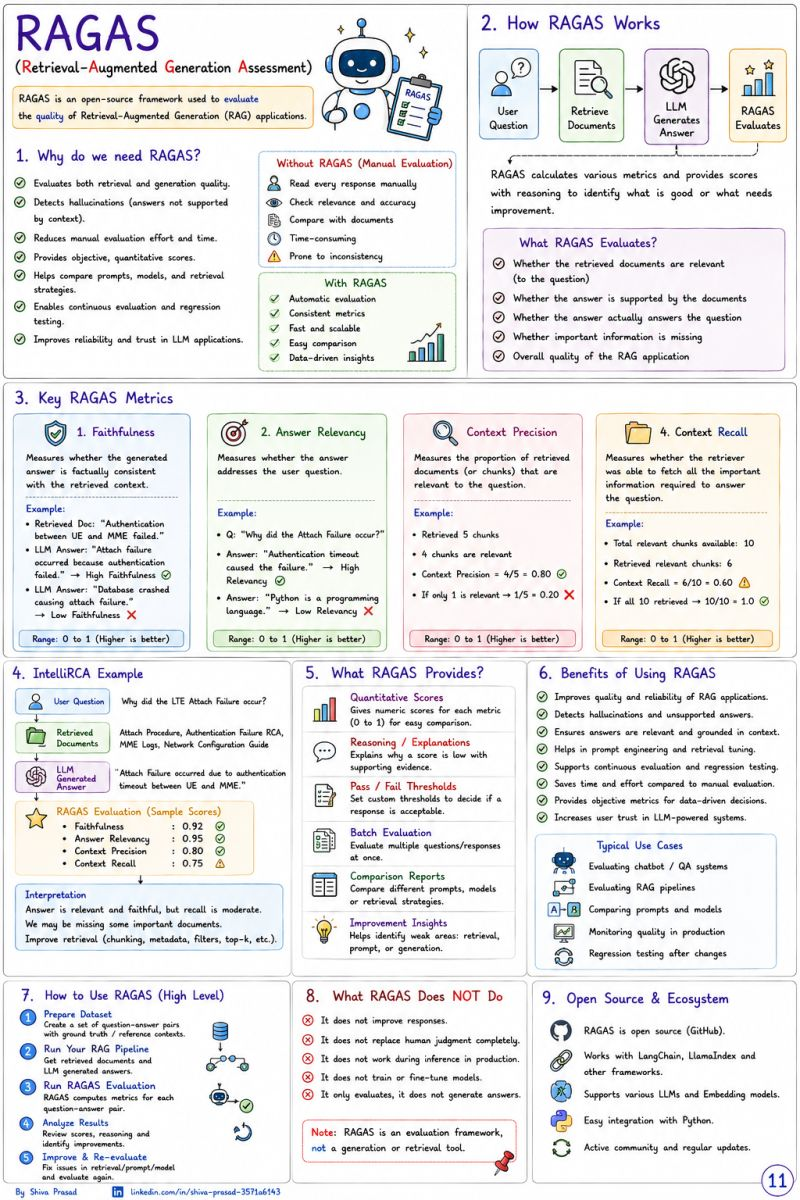

# 1.Qs) What problem can occur when a metadata filter is applied after similarity ranking rather than before it?

In most RAG systems, apply metadata filtering before or during vector search, not afterward. Many vector databases support this natively by combining metadata constraints with similarity search in a single query. This preserves both retrieval quality and efficiency.

Applying metadata filters after similarity ranking can discard many of the top-ranked results, leading to low recall or even empty results. Applying the filter before similarity search ensures the search is performed only over documents that satisfy the metadata constraints, resulting in more accurate and relevant retrieval.

# 2Q). Why is reciprocal rank fusion considered robust when combining a lexical ranking with a dense ranking?

--- It combines rankings using position alone, avoiding score rescaling

Reciprocal Rank Fusion is a ranking fusion technique that combines the ranked lists from multiple retrievers, such as BM25 and dense vector search, using their rank positions rather than their raw scores. This is important because lexical and dense retrievers produce scores on different scales that can't be compared directly. RRF rewards documents that appear near the top of either ranking, allowing it to combine the precision of keyword search with the semantic understanding of vector search. As a result, it improves recall, reduces dependence on any single retrieval method, and usually provides more robust retrieval performance for RAG applications.

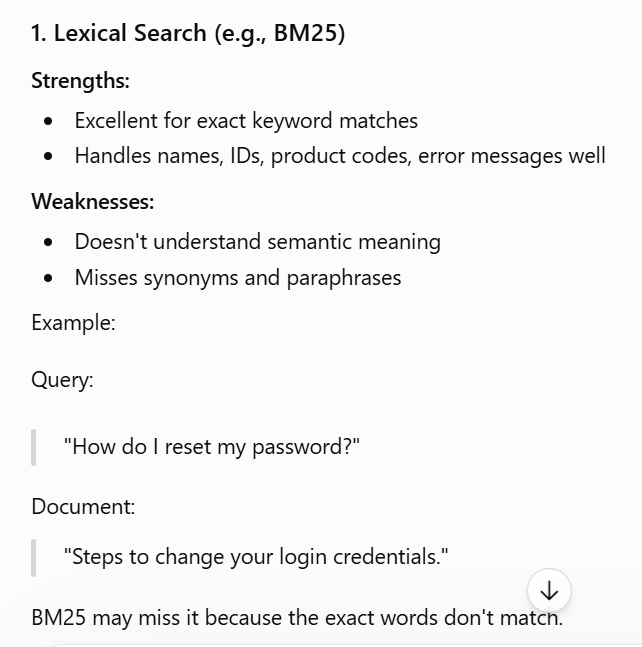

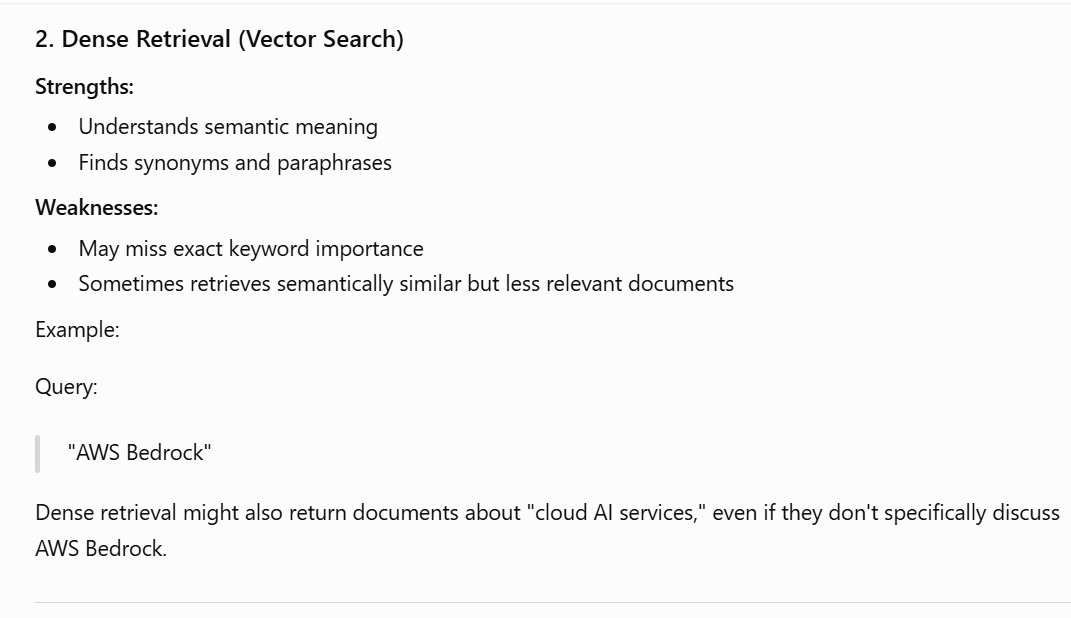

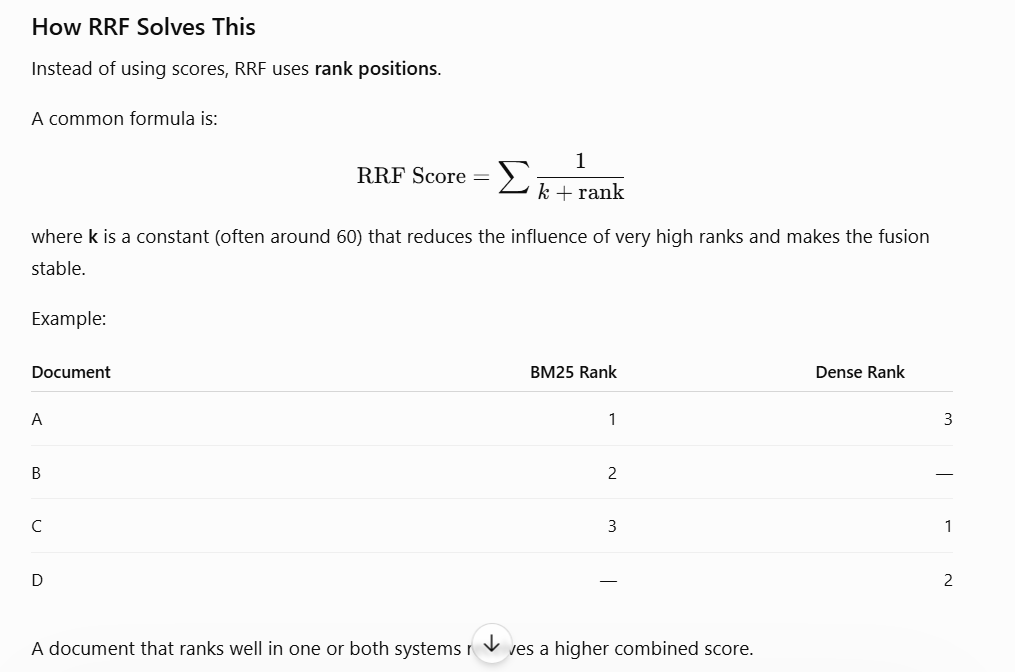

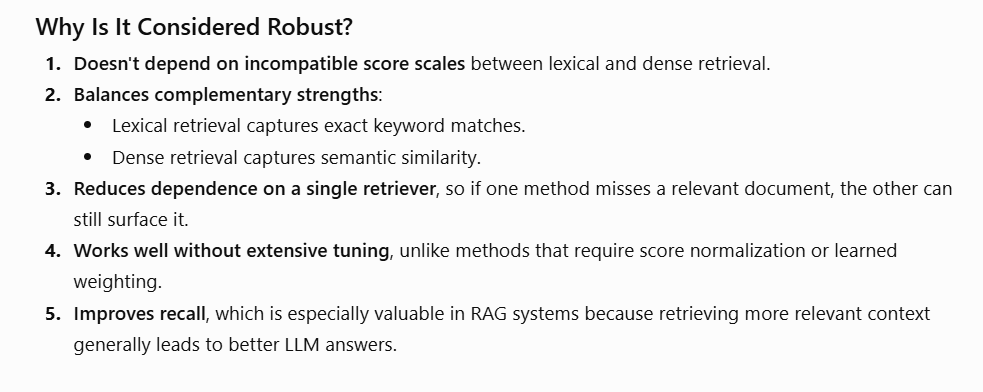

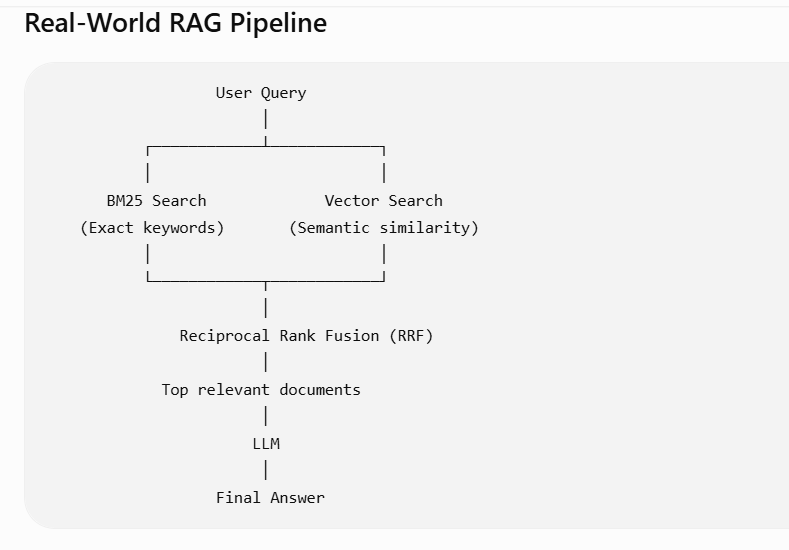

# BM25

BM25 (Best Matching 25) is a lexical retrieval algorithm that ranks documents based on keyword relevance. It considers three main factors: term frequency (how often a query term appears in a document), inverse document frequency (giving more weight to rare terms), and document length normalization (preventing long documents from being unfairly favored). BM25 is excellent for exact keyword searches but cannot understand semantic meaning, which is why it is often combined with vector search in modern RAG systems.


- Advantages

Very fast and efficient.

Great for exact keyword matching.

No model training required.

Widely used in search engines like Elasticsearch and OpenSearch.

# NDCG:-
NDCG (Normalized Discounted Cumulative Gain) is a ranking metric used to evaluate retrieval systems. It rewards highly relevant documents appearing near the top of the search results and penalizes relevant documents that appear lower in the ranking. The score is normalized between 0 and 1, where 1 represents the ideal ranking. In RAG systems, NDCG is used to evaluate how effectively the retriever orders relevant documents before they are passed to the LLM.

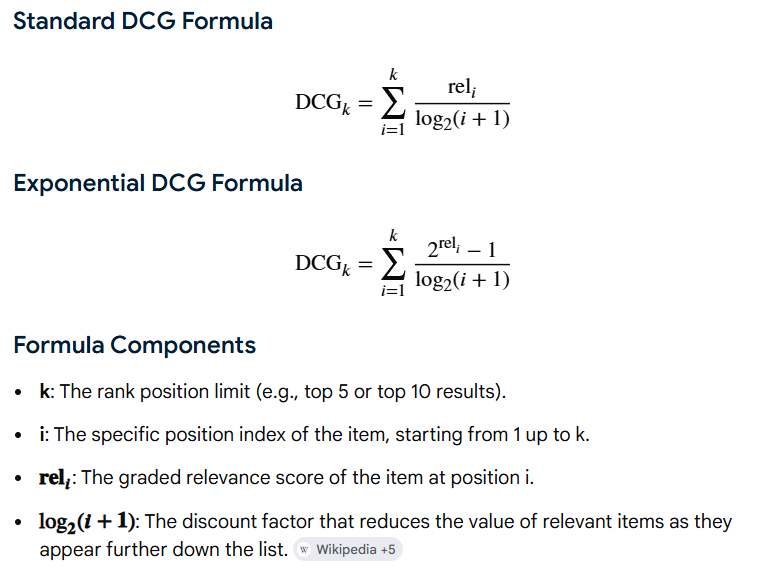

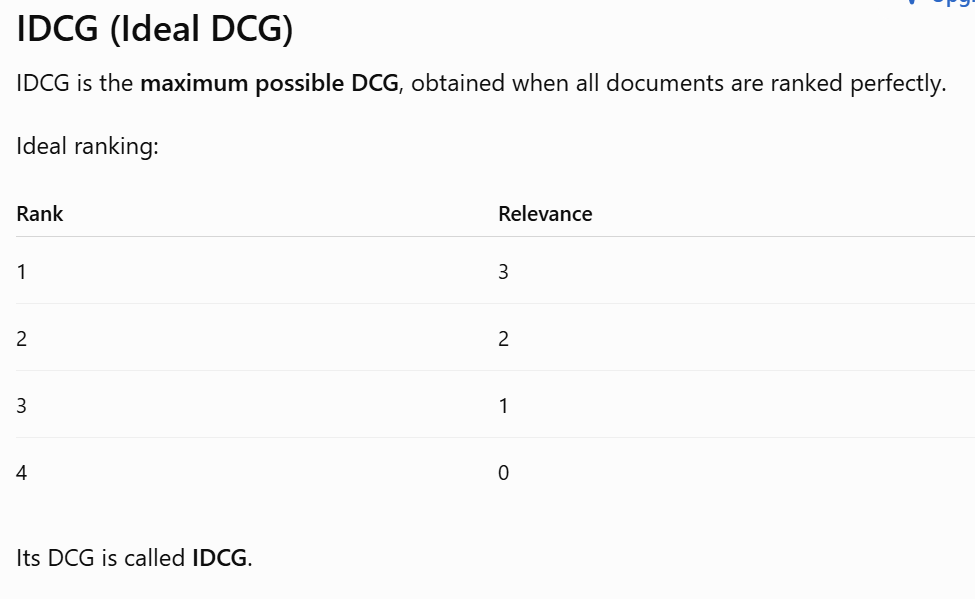

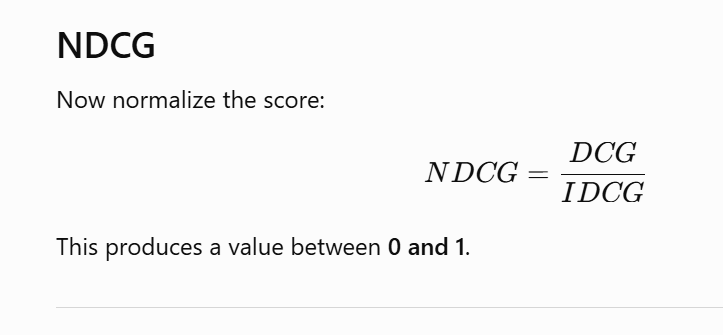

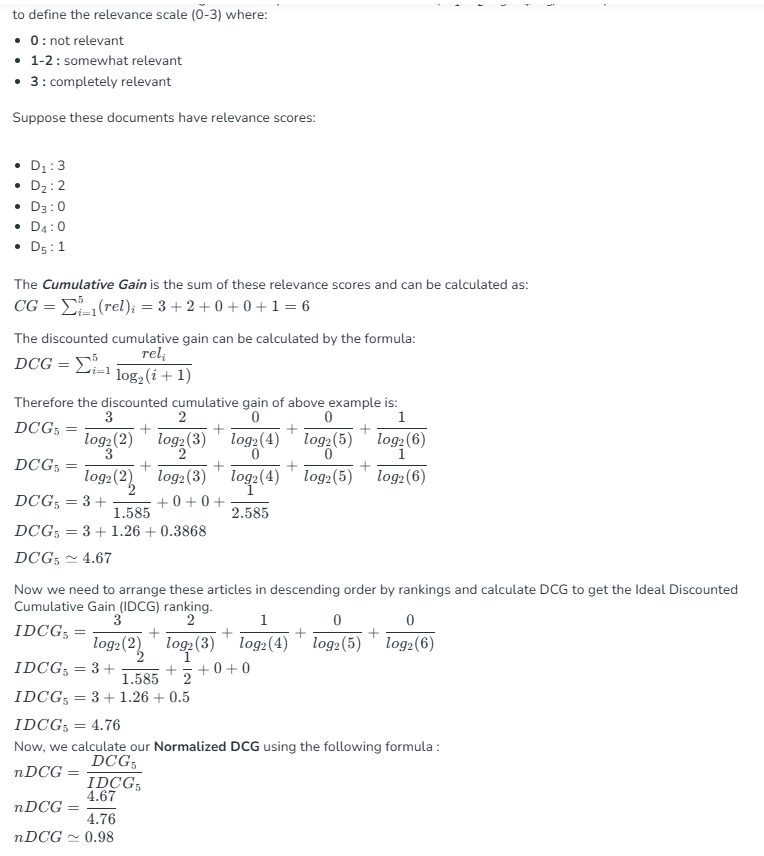

Limitations of Normalized Discounted Cumulative Gain (NDCG):

- NDCG metrics does not penalize the bad documents outputs. For Example: [3] and [3, 0, 0] has same NDCG but in second out there are two irrelevant documents.
- Because no specific standard defined for the number of output documents. DCG does not seem to deal with missing any relevant document in the output. For example, two outputs [3, 3, 3] and [3, 3, 3, 3] of similar input are considered equally good. For output-1 the DCG3 is calculated but for output-2 the DCG4 is calculated.